In [1]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import PIL 
import tensorflow as tf
import numpy as np
import os 
import matplotlib.pyplot as plt
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

I0000 00:00:1786949995.308950   31890 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786949996.949837   31890 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786950004.235804   31890 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flowers_photos", origin=dataset_url, cache_dir=".", untar=True)

In [3]:
data_dir

'./datasets/flowers_photos'

In [4]:
import pathlib

In [6]:
data_dir = pathlib.Path("datasets/flowers_photos/flower_photos")
data_dir

PosixPath('datasets/flowers_photos/flower_photos')

In [7]:
print(data_dir.exists())

True


In [8]:
print(list(data_dir.iterdir()))

[PosixPath('datasets/flowers_photos/flower_photos/tulips'), PosixPath('datasets/flowers_photos/flower_photos/sunflowers'), PosixPath('datasets/flowers_photos/flower_photos/roses'), PosixPath('datasets/flowers_photos/flower_photos/dandelion'), PosixPath('datasets/flowers_photos/flower_photos/daisy'), PosixPath('datasets/flowers_photos/flower_photos/LICENSE.txt')]


In [9]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [10]:
roses = list(data_dir.glob('roses/*'))
roses[:4]

[PosixPath('datasets/flowers_photos/flower_photos/roses/3292654244_4a220ab96f_m.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/5172171681_5934378f08.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/145862135_ab710de93c_n.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/5156037859_1673720a11_m.jpg')]

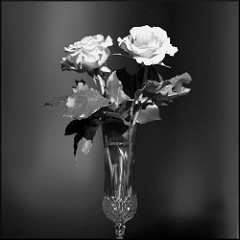

In [12]:
PIL.Image.open(str(roses[0]))

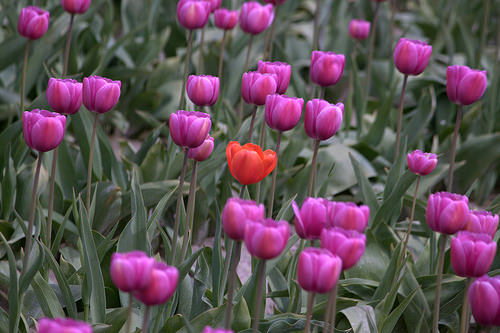

In [11]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(tulips[1])

In [12]:
flowers_image_dict = {
    "roses": list(data_dir.glob("roses/*")),
    "daisy": list(data_dir.glob("daisy/*")),
    "dandelion": list(data_dir.glob("dandelion/*")),
    "sunflowers": list(data_dir.glob("sunflowers/*")),
    "tulips": list(data_dir.glob("tulips/*"))
}

In [13]:
flowers_labels_dict = {
    "roses": 0,
    "daisy": 1,
    "dandelion": 2,
    "sunflowers": 3,
    "tulips": 4,
}

In [16]:
# lets convert every single image into numpy array with opencv

In [14]:
img = cv2.imread(flowers_image_dict['roses'][0])

In [15]:
img

array([[[ 25,  17,  18],
        [ 31,  25,  26],
        [ 29,  24,  25],
        ...,
        [ 26,  21,  22],
        [ 30,  25,  26],
        [ 15,  10,  11]],

       [[ 15,   9,  10],
        [ 34,  28,  29],
        [ 43,  38,  39],
        ...,
        [ 50,  48,  48],
        [ 39,  37,  37],
        [  5,   3,   3]],

       [[ 10,   5,   6],
        [ 39,  34,  35],
        [ 54,  52,  52],
        ...,
        [ 66,  66,  66],
        [ 46,  46,  46],
        [  0,   0,   0]],

       ...,

       [[ 17,  12,  13],
        [ 18,  16,  16],
        [ 19,  19,  19],
        ...,
        [106, 106, 106],
        [ 78,  78,  78],
        [  0,   0,   0]],

       [[ 15,  10,  11],
        [ 13,  11,  11],
        [ 11,  11,  11],
        ...,
        [ 66,  66,  66],
        [ 50,  50,  50],
        [  3,   3,   3]],

       [[  9,   4,   5],
        [  4,   2,   2],
        [  0,   0,   0],
        ...,
        [  2,   2,   2],
        [  4,   4,   4],
        [  0,   0,   0]]

In [19]:
img.shape

(240, 240, 3)

In [20]:
cv2.resize(img, (180, 180)).shape

(180, 180, 3)

In [16]:
X, y = [], []

for flower_name, images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (180, 180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [17]:
X[1].shape

(180, 180, 3)

In [18]:
X = np.array(X)
y = np.array(y)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [20]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [22]:
num_classes = 5

model = Sequential([
    # 16 means filters, 3 means 3x3 kernel size
    layers.Conv2D(16, 3, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes)
])

In [23]:
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)

E0000 00:00:1786950200.598172   31890 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
model.fit(X_train_scaled, y_train, epochs = 10)

In [ ]:
model.evaluate(X_test_scaled, y_test)

In [ ]:
predictions = model.predict(X_test_scaled)

In [ ]:
score = tf.nn.softmax(predictions[0])

In [ ]:
np.argmax(score)

In [ ]:
y_test[0]

In [ ]:
# handling data augmentation

In [ ]:
data_augmentation = keras.Sequential([
    # layers.experimental.preprocessing.RandomZoom(0.3) # you can adjust this value to see the difference
    # layers.experimental.preprocessing.RandomContrast(0.9) # you can adjust this value to see the difference
    layers.experimental.preprocessing.RandomRotation(0.3) # you can adjust this value to see the difference
])

In [ ]:
plt.axis("off")
plt.imshow(X[0])

In [ ]:
plt.axis("off")
plt.imshow(data_augmentation(X)[0].numpy().astype("unit8")) # you see that the image is zoomed

In [ ]:
data_augmentation = keras.Sequential([
    layers.experimental.preprocessing.RandomFlip(
        "horizontal", input_shape=(img_height, img_width, 3)
    ),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1)
])

In [ ]:
num_classes = 5

model = Sequential([
    data_augmentation,
    # 16 means filters, 3 means 3x3 kernel size
    layers.Conv2D(16, 3, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding = "same", activation = "relu"),
    layers.Dropout(0.2)
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes)
])